In [2]:
#@title Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


In [8]:
df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [10]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

In [11]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['embarked'] = encoder.fit_transform(df['embarked'])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


<Axes: >

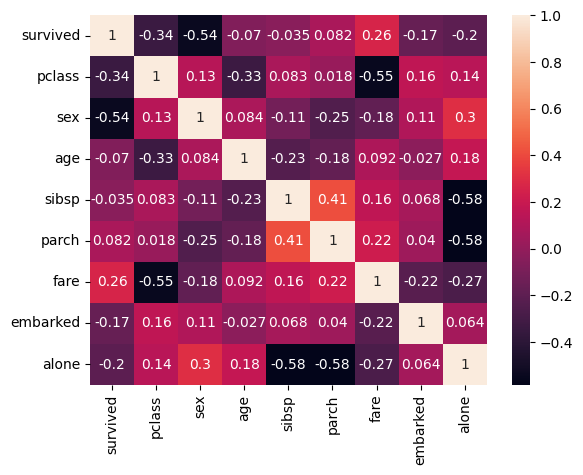

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [15]:
df_less = df.copy()
df_less.drop(['age', 'sibsp', 'parch'],axis=1, inplace=True)

In [16]:
df_less.head()

,survived,pclass,sex,fare,embarked,alone
0,0,3,1,7.2500,2,False
1,1,1,0,71.2833,0,False
2,1,3,0,7.9250,2,True
3,1,1,0,53.1000,2,False
4,0,3,1,8.0500,2,True


In [17]:
X = df.drop("survived", axis=1)
y = df['survived']

X_less = df_less.drop("survived", axis=1)
y_less = df_less['survived']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train_less, X_test_less, y_train_less, y_test_less = train_test_split(X_less,y_less, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression()
model_less = LogisticRegression()

model.fit(X_train, y_train)
model_less.fit(X_train_less, y_train_less)

LogisticRegression()

In [20]:
y_pred = model.predict(X_test)
y_pred_less = model_less.predict(X_test_less)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

#for lesser data
print(accuracy_score(y_test_less, y_pred_less))
print(classification_report(y_test_less, y_pred_less))
print(confusion_matrix(y_test_less, y_pred_less))

0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

[[90 15]
 [20 54]]
0.7653631284916201
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       105
           1       0.70      0.77      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.77      0.77      0.77       179

[[80 25]
 [17 57]]


# KNN (K-Nearest Neighbor)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [25]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [26]:
print(accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

0.8379888268156425
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       105
           1       0.84      0.76      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

[[94 11]
 [18 56]]


# Naive Bayes Algorithm

For Naive Bayes, we don't usually need scaled Data

In [27]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [28]:
y_pred_nb = nb_model.predict(X_test)

In [29]:
print(accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

0.776536312849162
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179

[[82 23]
 [17 57]]


# Decision Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Decision Trees and KNN require scaled data

In [46]:
y_pred_dcstree = dt_model.predict(X_test_scaled)

In [47]:
print(accuracy_score(y_test, y_pred_dcstree))
print(classification_report(y_test, y_pred_dcstree))
print(confusion_matrix(y_test, y_pred_dcstree))

0.7988826815642458
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

[[92 13]
 [23 51]]


In [48]:
from sklearn import tree

[Text(0.5, 0.875, 'x[1] <= -0.328\ngini = 0.469\nsamples = 712\nvalue = [444, 268]'),
 Text(0.25, 0.625, 'x[0] <= 0.206\ngini = 0.386\nsamples = 245\nvalue = [64, 181]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[2] <= -2.082\ngini = 0.074\nsamples = 130\nvalue = [5, 125]'),
 Text(0.0625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1875, 0.125, 'gini = 0.061\nsamples = 128\nvalue = [4, 124]'),
 Text(0.375, 0.375, 'x[5] <= -0.178\ngini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]'),
 Text(0.3125, 0.125, 'gini = 0.486\nsamples = 94\nvalue = [39, 55]'),
 Text(0.4375, 0.125, 'gini = 0.091\nsamples = 21\nvalue = [20, 1]'),
 Text(0.75, 0.625, 'x[2] <= -1.774\ngini = 0.303\nsamples = 467\nvalue = [380, 87]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[3] <= 1.656\ngini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.6875, 0.125, 'gini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.875,

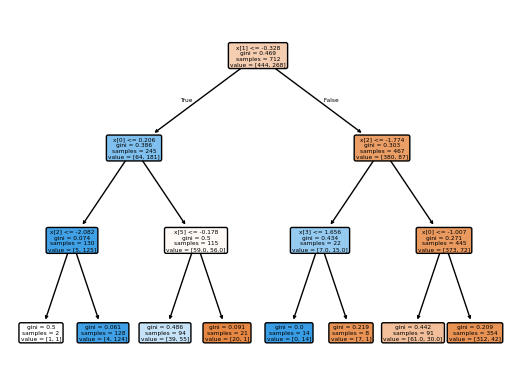

In [50]:
tree.plot_tree(dt_model, max_depth=3, filled=True, rounded=True)

# SVM (Support Vector Machines)

SVM also uses scaled data

In [51]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)

SVC()

In [52]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [53]:
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

0.8156424581005587
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

[[92 13]
 [20 54]]
